# Business Analytics Case Study: Customer Behaviour & Business Performance Analysis
### AnalystLab Africa — Data Analytics Internship Programme
**Week 1 Assignment**

**Prepared by:** Osagie Osagieduwa Precious (Preshy)
**Role:** Junior Data Analyst, AnalystLab Africa Consulting
**Client:** ABC Communications Ltd
**Dataset:** [Telco Customer Churn Dataset (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


---
## Part 1 — Business Understanding Report

### Background
ABC Communications Ltd is a telecommunications provider offering phone and internet services (DSL and Fibre optic), along with value-added services such as online security, tech support, device protection, and streaming. Like most subscription-based telecom businesses, ABC Communications faces the ongoing challenge of **customer churn** — the loss of subscribers who cancel or switch to a competitor.

### The Business Problem
Customer churn directly erodes recurring revenue and increases the cost of doing business, since acquiring a new customer is significantly more expensive than retaining an existing one. ABC Communications has engaged AnalystLab Africa Consulting to investigate **why customers churn**, **which customer segments are most at risk**, and to recommend **data-driven retention strategies**.

### Why Churn Matters
- **Revenue impact**: Every churned customer represents lost recurring monthly revenue and a sunk acquisition cost.
- **Competitive pressure**: Telecom is a saturated market with low switching costs, making retention a key competitive lever.
- **Customer lifetime value (CLV)**: Long-tenured customers are typically far more profitable than new ones, so early-tenure churn is especially costly.

### Objectives of This Analysis
1. Understand the structure and quality of the customer dataset.
2. Identify which customer segments (by contract, tenure, services, payment method, demographics) show the highest churn.
3. Visualise churn patterns to make them actionable for business stakeholders.
4. Translate findings into concrete risks, opportunities, and recommendations for the retention strategy team.

### Approach
This report follows the CRISP-DM-style analytics workflow: business understanding, data inspection, exploratory analysis with visualisation, insight generation, and actionable recommendation — the same workflow used throughout, from raw data to final leadership presentation.


---
## Part 2 — Data Loading & Inspection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Shape of the dataset
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


In [3]:
# Column names and data types
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
# Missing values per column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# Duplicate rows and duplicate customer IDs
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate customerID values:", df['customerID'].duplicated().sum())

Fully duplicated rows: 0
Duplicate customerID values: 0


In [6]:
# TotalCharges is stored as text — inspect and convert
non_numeric = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"Rows where TotalCharges is not numeric: {len(non_numeric)}")
non_numeric[['customerID', 'tenure', 'TotalCharges']]

Rows where TotalCharges is not numeric: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [7]:
# Convert TotalCharges to numeric. The blank values all belong to customers
# with tenure == 0 (i.e. brand new customers who have not yet been billed),
# so we fill them with 0 rather than dropping the rows.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# SeniorCitizen is 0/1 — map to Yes/No for readability in charts
df['SeniorCitizenLabel'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

df.isnull().sum().sum()  # confirm 0 missing values remain

np.int64(0)

In [8]:
# Summary statistics — numeric columns
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [9]:
# Summary statistics — categorical columns
df.describe(include='object')

/tmp/ipykernel_549/1695378061.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,SeniorCitizenLabel
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174,5901


### Dataset Inspection Summary
- The raw dataset contains **7,043 customer records** and **21 columns**.
- There are **no duplicate rows** and **no duplicate `customerID` values** — each row represents a unique customer.
- **No column contains true missing (NaN) values**, but `TotalCharges` was stored as text and contained **11 blank entries**. All 11 belong to customers with `tenure = 0` (i.e. brand-new customers not yet billed) — these were converted to numeric and filled with 0.
- The target variable, `Churn`, is imbalanced: roughly **73.5% "No" vs 26.5% "Yes"** — this is addressed further in Part 3.
- Most fields are categorical (service subscriptions, contract type, payment method), with `tenure`, `MonthlyCharges`, and `TotalCharges` as the core numeric fields.


---
## Part 3 — Business Data Analysis

### 3.1 Overall Churn Distribution (Pie Chart)


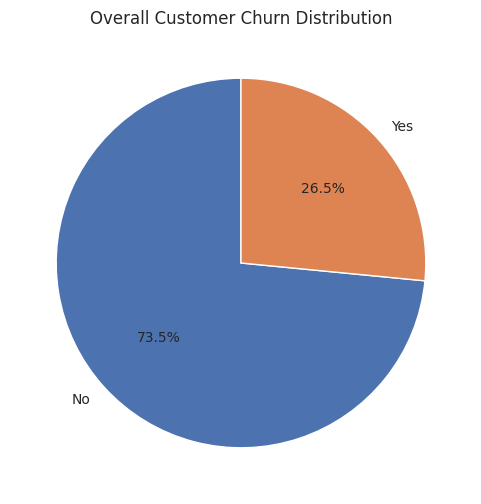

In [10]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452'], startangle=90,
        wedgeprops={'edgecolor': 'white'})
plt.title('Overall Customer Churn Distribution')
plt.show()

**Interpretation:** About **26.5%** of ABC Communications' customer base has churned, versus 73.5% retained. A churn rate above a quarter of the customer base is high for a subscription business and signals a material revenue risk worth investigating segment by segment.


### 3.2 Contract Type Distribution (Pie Chart)

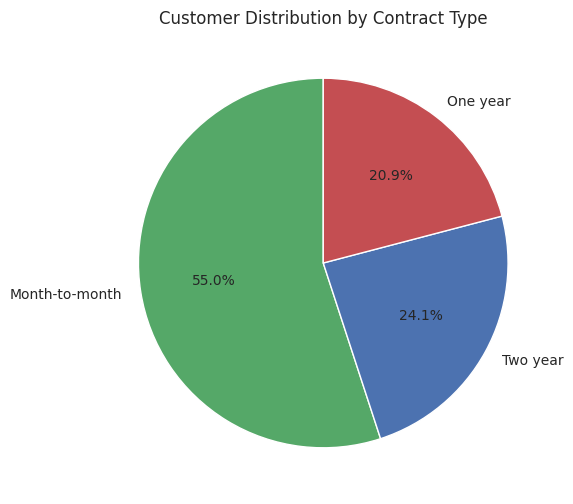

In [11]:
contract_counts = df['Contract'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(contract_counts, labels=contract_counts.index, autopct='%1.1f%%',
        colors=['#55A868', '#4C72B0', '#C44E52'], startangle=90,
        wedgeprops={'edgecolor': 'white'})
plt.title('Customer Distribution by Contract Type')
plt.show()

**Interpretation:** **55%** of customers are on flexible **Month-to-month** contracts, compared to 21% on One-year and 24% on Two-year contracts. This large short-commitment base is important context for the churn-by-contract finding below.


### 3.3 Churn Rate by Contract Type (Bar Chart)

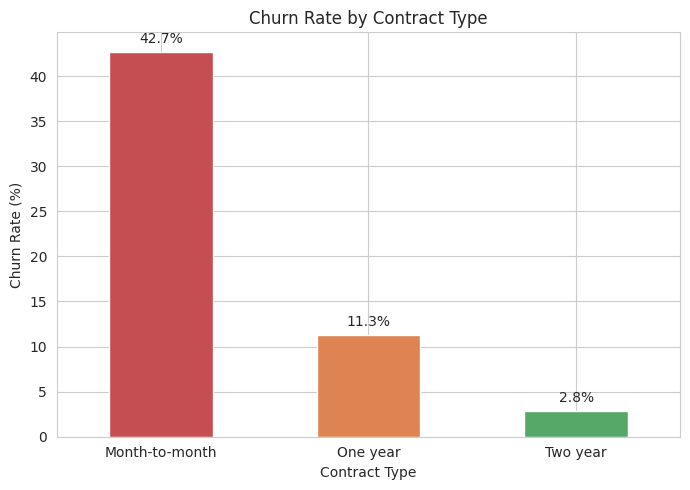

In [12]:
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
churn_by_contract = churn_by_contract.reindex(['Month-to-month', 'One year', 'Two year'])

plt.figure(figsize=(7, 5))
ax = churn_by_contract.plot(kind='bar', color=['#C44E52', '#DD8452', '#55A868'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
for i, v in enumerate(churn_by_contract):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

**Interpretation:** Contract type is one of the strongest churn drivers in this dataset. **Month-to-month customers churn at 42.7%**, compared to **11.3% for One-year** and just **2.8% for Two-year** contracts. Customers with no long-term commitment are roughly **15x more likely to churn** than those on two-year contracts.


### 3.4 Churn Rate by Internet Service Type (Bar Chart)

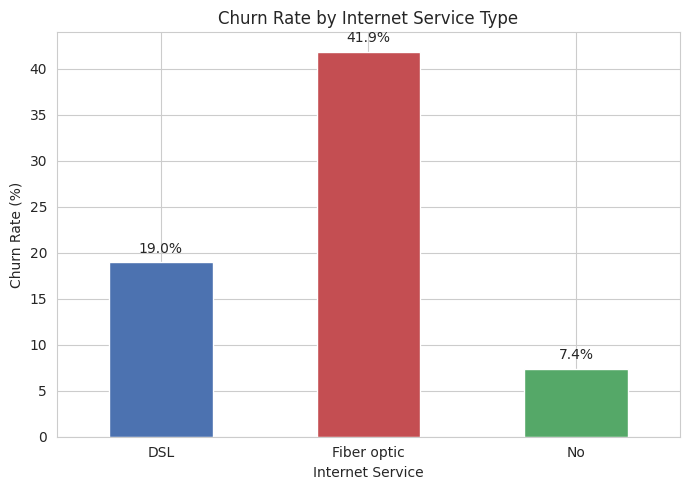

In [13]:
churn_by_internet = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

plt.figure(figsize=(7, 5))
ax = churn_by_internet.plot(kind='bar', color=['#4C72B0', '#C44E52', '#55A868'])
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Internet Service')
plt.xticks(rotation=0)
for i, v in enumerate(churn_by_internet):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

**Interpretation:** Customers on **Fibre optic** internet churn at **41.9%**, far higher than DSL (19.0%) or customers with no internet service (7.4%). This is counter-intuitive since fibre is the premium product — it likely reflects a combination of higher price sensitivity and possibly service-quality or competitive pressure specific to fibre customers.


### 3.5 Churn Rate by Payment Method (Bar Chart)

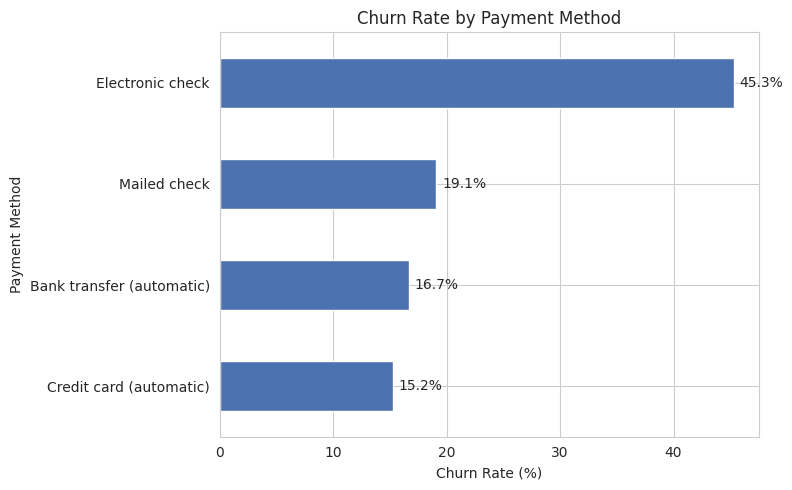

In [14]:
churn_by_payment = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values()

plt.figure(figsize=(8, 5))
ax = churn_by_payment.plot(kind='barh', color='#4C72B0')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')
for i, v in enumerate(churn_by_payment):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

**Interpretation:** Customers paying via **Electronic check churn at 45.3%** — more than double the next-highest method (Mailed check, 19.1%) and nearly three times the automatic payment methods (Bank transfer 16.7%, Credit card 15.2%). Manual, non-automated payment appears strongly associated with disengagement and churn.


### 3.6 Tenure Distribution (Histogram)

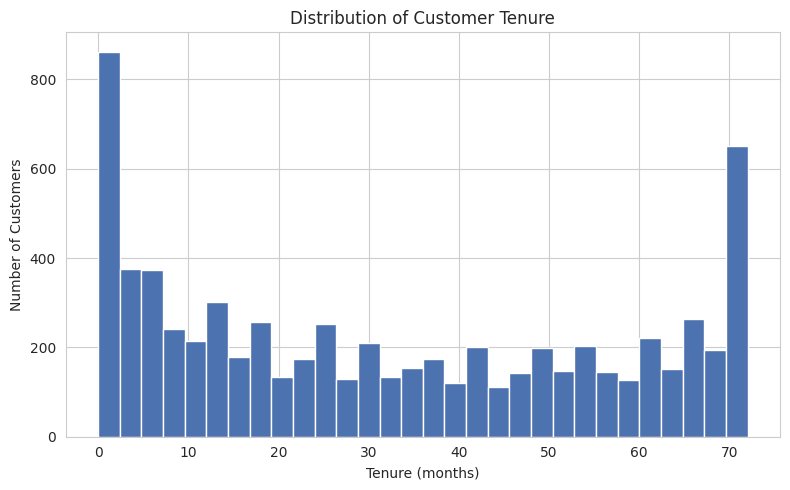

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df['tenure'], bins=30, color='#4C72B0', edgecolor='white')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Interpretation:** The tenure distribution is bimodal — a large spike of customers in their **first few months** and another large group near the **72-month (6-year) mark**. This suggests a two-tier customer base: a high-risk group of very new customers, and a loyal, long-tenured core.


### 3.7 Monthly Charges Distribution (Histogram)

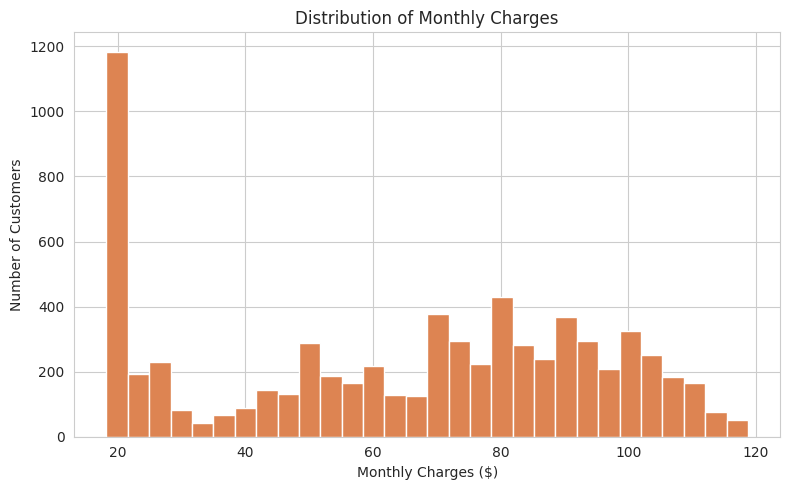

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df['MonthlyCharges'], bins=30, color='#DD8452', edgecolor='white')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Interpretation:** Monthly charges are spread across a wide range, with a large cluster of low-spend customers (around \$20, likely phone-only subscribers) and a broad hump between \$70–\$100 (bundled internet + add-on service customers).


### 3.8 Monthly Charges by Churn Status (Box Plot)

/tmp/ipykernel_549/2553851913.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#4C72B0', '#C44E52'])


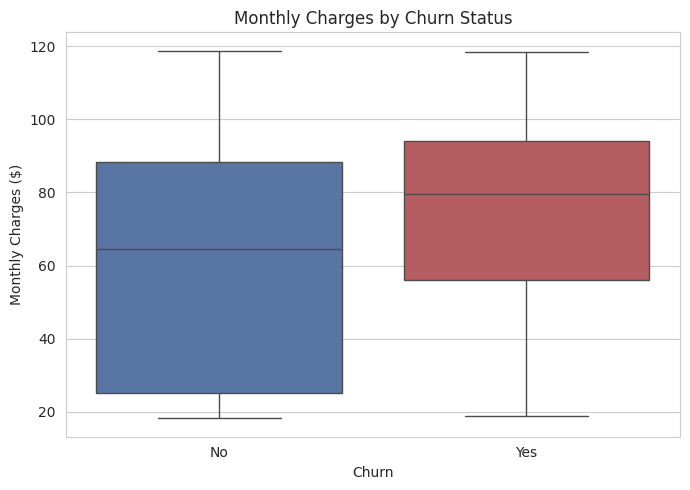

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#4C72B0', '#C44E52'])
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

**Interpretation:** Churned customers have a noticeably higher median monthly charge (~\$79) than retained customers (~\$64), and the interquartile range for churned customers sits higher overall. This reinforces the earlier finding that higher-priced fibre/bundle customers are more churn-prone — price may be a friction point even though these customers pay for premium service.


### 3.9 Correlation Heatmap

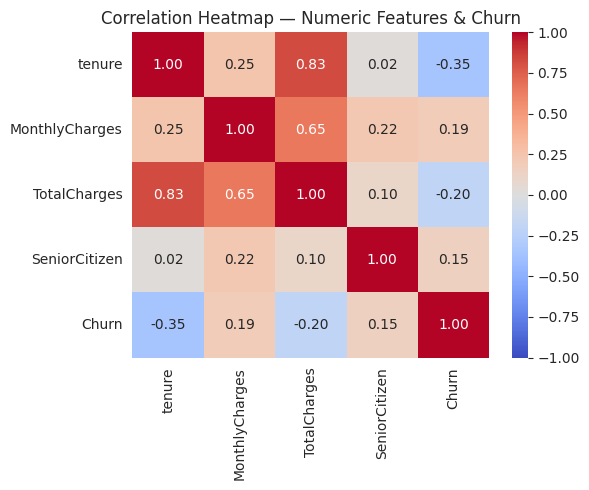

In [18]:
corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
corr_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features & Churn')
plt.tight_layout()
plt.show()

**Interpretation:** `tenure` has the strongest relationship with churn among numeric fields (**r = -0.35**) — longer-tenured customers are meaningfully less likely to churn. `MonthlyCharges` correlates positively with churn (**r = 0.19**), consistent with the box plot above. `TotalCharges` is strongly correlated with `tenure` (**r = 0.83**), as expected since it accumulates over time, and is therefore not an independent churn driver in its own right.


---
## Part 4 — Business Insights

### Key Insights
1. **Contract length is the single strongest churn predictor.** Month-to-month customers churn at 42.7%, versus 11.3% for one-year and just 2.8% for two-year contracts — a ~15x gap between the extremes.
2. **Fibre optic customers churn at nearly double the company average** (41.9% vs. 26.5% overall), despite being the premium product line, suggesting a price, competition, or service-quality issue specific to fibre.
3. **Electronic check payers churn at 45.3%**, dramatically higher than customers on automatic payment methods (15–17%), pointing to a link between payment friction/engagement and retention.
4. **Tenure is protective.** Churned customers have an average tenure of just 18.0 months vs. 37.6 months for retained customers, and churn risk is concentrated heavily in the first year.
5. **Customers without add-on protection services churn far more.** Customers with no Online Security or no Tech Support churn at ~41–42%, compared to ~15% for those who have these services — well above the customers with no internet service at all (7.4%), who have the lowest churn of any group.

### Business Risks
1. **Revenue concentration risk in month-to-month customers**: over half the customer base (55%) sits in the highest-risk contract tier, exposing a large share of revenue to short-notice cancellation.
2. **Premium product erosion**: high churn on fibre optic (the higher-margin service) threatens the most valuable revenue segment disproportionately.
3. **Early-tenure attrition**: a large cohort of very new customers (visible in the tenure histogram) represents unrecovered acquisition cost if they churn before becoming profitable.

### Business Opportunities
1. **Contract upgrade incentives**: converting even a portion of month-to-month customers to one- or two-year contracts could meaningfully cut overall churn, given the ~15x churn-rate gap between tiers.
2. **Add-on service bundling**: proactively offering Online Security and Tech Support (both associated with ~26-point lower churn) can be positioned as a retention lever, not just an upsell.
3. **Payment method migration**: campaigns encouraging Electronic check users to switch to automatic bank transfer or credit card payment could reduce churn among the highest-risk payment segment.


---
## Part 5 — Business Recommendations

1. **Launch a contract-conversion campaign** targeting month-to-month customers with discounted pricing or added perks for switching to one- or two-year contracts, prioritising customers in their first 12 months (the highest-risk window).
2. **Investigate the fibre optic experience** — review pricing, service quality, and competitor offers specifically for fibre customers, since this segment churns nearly 2x the company average despite being the premium tier.
3. **Incentivise a shift away from Electronic check payments** by offering a small discount or reward for enrolling in automatic bank transfer or credit card payment, targeting the segment with the highest churn rate (45.3%).
4. **Bundle Online Security and Tech Support into onboarding** for new customers at little or no extra cost for the first few months, since both services are strongly associated with lower churn.
5. **Create a structured first-90-days retention programme** (proactive check-ins, onboarding support, early-tenure discounts) to address the concentration of churn among new customers before they build long-term loyalty.
6. **Build a churn-risk scoring model** using the strongest predictors identified here (contract type, tenure, internet service, payment method) to flag at-risk customers for proactive retention outreach before they cancel.


---
## Conclusion

Customer churn at ABC Communications Ltd is concentrated in identifiable, addressable segments: **month-to-month contract holders, fibre optic subscribers, Electronic check payers, and early-tenure customers**. These four factors, more than demographics, are the clearest levers available to the retention team. Acting on contract structure, payment method, and add-on service bundling offers the most direct path to reducing the current 26.5% churn rate.
